# 3. Ecosystem Transition - Output cleaning

In [1]:
import rasterio
from rasterio.mask import mask
from rasterio.plot import show
from rasterio.windows import from_bounds
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import geopandas as gpd
import numpy as np

In [2]:
#BM_analysis_path = "home/emulder/biomass_pre_post_transition_NA.tif"
BM_analysis_path = "biomass_pre_post_transition_WY.tif"
NC_RISCC_shp_path = "data/iplant/home/shared/earthlab/NC_eco_transformations/NC_CASC_region.shp"
output_tif = "BM_pre_post_transition_WY_clip.tif"
state_abbr = "WY" # Available states: CO, KS, NE, MT, ND, SD, WY
#output_tif_permanent = "home/emulder/BM_Trans_Analysis_Outputs/BM_pre_post_transition_NE.tif"
output_tif_permanent = "/home/jovyan/data-store/test_bm/BM_pre_post_transition_WY.tif" #home/shared/earthlab/NC_eco_transformations/BM_analysis/BM_pre_post_transition_WY.tif""

In [3]:
input_tif = BM_analysis_path
output_tif = output_tif
states = gpd.read_file(NC_RISCC_shp_path)

# --- Filter to state ---
state_abbr = state_abbr
state_shape = states[states["STATE_ABBR"] == state_abbr]

# Check we got one feature
if state_shape.empty:
    raise ValueError(f"No features found for STATE_ABBR = '{state_abbr}'")

# --- Open the raster and clip ---
with rasterio.open(input_tif) as src:
    # Ensure CRS match
    if state_shape.crs != src.crs:
        state_shape = state_shape.to_crs(src.crs)

    # Convert geometry to GeoJSON-like dict
    geoms = [geom.__geo_interface__ for geom in state_shape.geometry]

    # Clip raster using the selected state's geometry
    data, transform = mask(src, geoms, crop=True, filled=True)

    # Update metadata
    meta = src.meta.copy()
    meta.update({
        "height": data.shape[1],
        "width": data.shape[2],
        "transform": transform,
        "nodata": src.nodata if src.nodata is not None else -9999,
    })

# --- Save the clipped raster ---
with rasterio.open(output_tif, "w", **meta) as dest:
    dest.write(data)

print(f"Clipped raster saved to: {output_tif}")

DriverError: data/iplant/home/shared/earthlab/NC_eco_transformations/NC_CASC_region.shp: No such file or directory

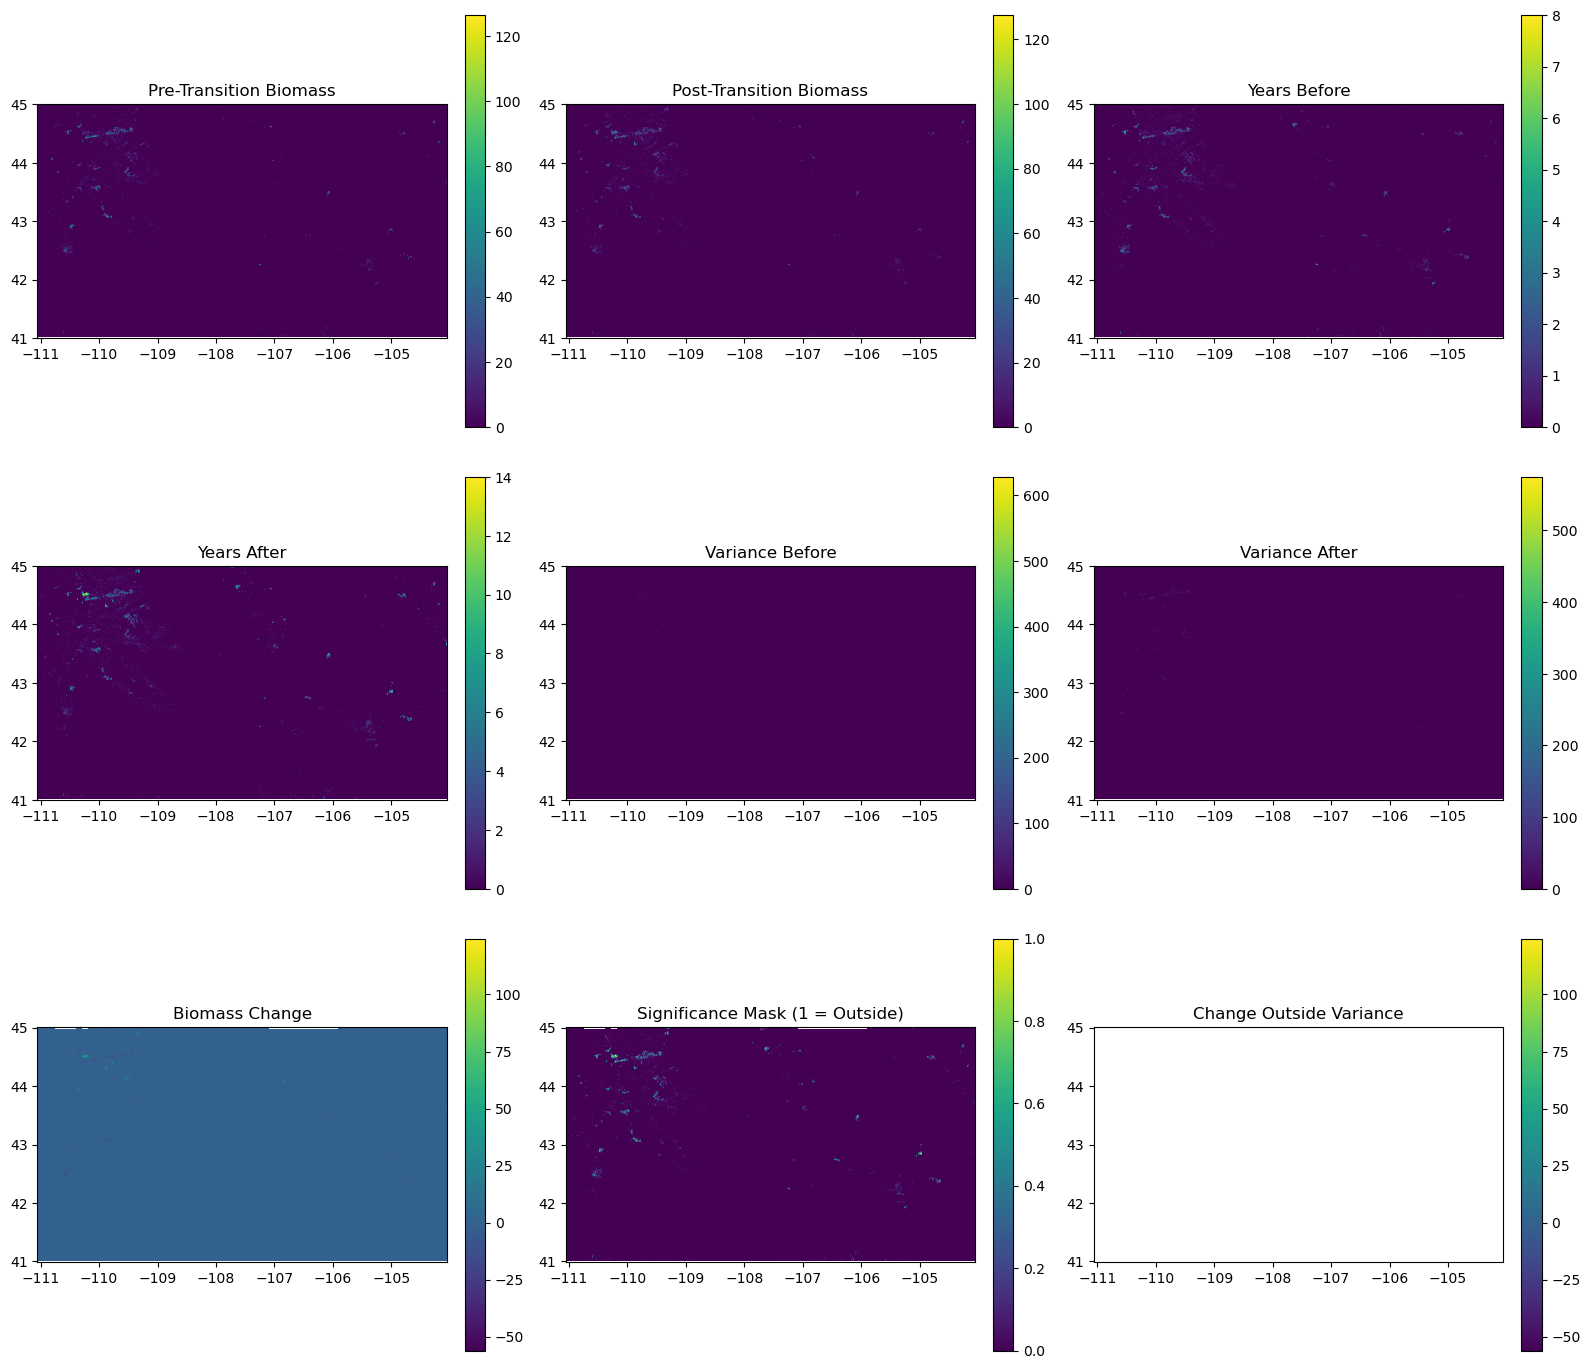

In [26]:
with rasterio.open(output_tif) as src:
    data = src.read(masked=True)
    extent = rasterio.plot.plotting_extent(src)

titles = [
    "Pre-Transition Biomass",
    "Post-Transition Biomass",
    "Variance Before",
    "Variance After",
    "Biomass Change",
    "Significance Mask (1 = Outside)",
    "Change Outside Variance",
    "Transition Year"
]

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
for i, ax in enumerate(axes.flat[:8]):
    im = ax.imshow(data[i], cmap='viridis', extent=extent)
    ax.set_title(titles[i])
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

In [27]:
write output to permanent storage
output_tif = output_tif_permanent
with rasterio.open(output_tif, "w", **meta) as dest:
    dest.write(data)